In [1]:
from functools import partial

import colorcet as cc
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import scipy.spatial as scspatial
from dynamical_systems.continuous import Lorenz63
from dynamical_systems.dataset import TimeSeriesDataset
from dynamics_discovery.models import LatentLSTM
from dynamics_discovery.preprocessing import standardize
from jaxtyping import Array, Float
import optax


jax.config.update("jax_enable_x64", True)
plt.style.use("matplotlib_utils.styles.dash_gridded")

In [2]:
dataset_loaded = TimeSeriesDataset.load("./data/lorenz63.hdf5")[30000:]
t_train = dataset_loaded.t[0]
u_orig = dataset_loaded.u[0]
u_train = standardize(u_orig)
u_std = jnp.std(u_orig, axis=0)

lorenz = Lorenz63()

## Calculate the ground truth one step jacobian of the ODE system


In [3]:
def step(ode, t0, t1, u0):
    sol = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        dfx.Tsit5(),
        t0,
        t1,
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
        args=None,
    )
    return sol.ys[0]


@partial(eqx.filter_vmap, in_axes=(None, 0, 0, None))
def jacobian_one_step(ode, t, u, dt):
    @eqx.filter_jacrev
    def _jac_step(t_u):
        t, u = t_u
        return step(ode, t, t + dt, u)

    return _jac_step((t, u))[1]

In [4]:
u_orig.shape

(100000, 3)

In [5]:
jac_unscaled = jacobian_one_step(lorenz, t_train, u_orig, t_train[1] - t_train[0])
jac_unscaled.shape
jac_true = jnp.diag(1 / u_std) @ jac_unscaled @ jnp.diag(u_std)
jac_true.shape

(100000, 3, 3)

In [6]:
kdtree = scspatial.KDTree(u_train[:-1])

num_neighbors = 10
_, idx_nn_ = kdtree.query(u_train[:-1], k=num_neighbors + 1)
idx_nn = idx_nn_[:, 1:]

In [7]:
idx_nn.shape

(99999, 10)

In [8]:
example_ind = 30


@partial(eqx.filter_vmap, in_axes=(None, 0, 0))
def estimate_jacobian(us: Float[Array, "time dim"], idx, idx_nn):
    u0, u1 = us[idx], us[idx + 1]
    u_nn0 = jnp.take(us, idx_nn, axis=0)
    u_nn1 = jnp.take(us, idx_nn + 1, axis=0)

    du0 = u_nn0 - u0
    du1 = u_nn1 - u1
    return (jnp.linalg.pinv(du0) @ du1).T


jac_linregress = estimate_jacobian(u_train, jnp.arange(u_train.shape[0] - 1), idx_nn)


In [9]:
def relative_error(
    y_pred: Float[Array, " batch *rest"],
    y_true: Float[Array, " batch *rest"],
    axis: int = -1,
    ord: int | None = None,
):
    norm_true = jnp.linalg.norm(y_true, ord=ord, axis=axis)
    norm_err = jnp.linalg.norm(y_pred - y_true, ord=ord, axis=axis)
    return norm_err / norm_true


err_linregress = relative_error(jac_linregress, jac_true[:-1], axis=(-2, -1))

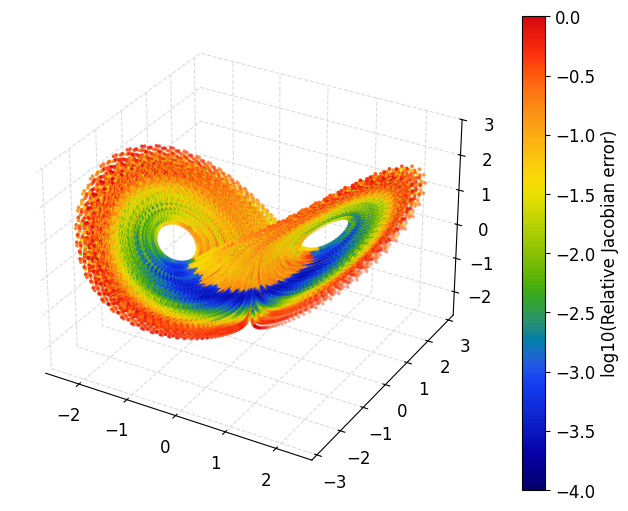

In [10]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(7, 5),
    subplot_kw={"projection": "3d"},
)
plot = ax.scatter(
    *u_train[:-1].T,
    c=jnp.log10(err_linregress),
    s=3,
    cmap=cc.cm.rainbow4,
    vmin=-4,
    vmax=0.0,
)
fig.colorbar(
    plot,
    ax=ax,
    label=r"log10(Relative Jacobian error)",
)

## Jacobian estimation via neural network

In [35]:
from functools import partial


def estimate_step_error(
    model,
    t0: Float[Array, ""],
    u0: Float[Array, " dim"],
    du0: Float[Array, "samples dim"],
    dt: Float[Array, ""],
):
    def _step(u):
        return model.step(t0, t0 + dt, u)

    @partial(eqx.filter_vmap, in_axes=(None, 0))
    def _step_error(u, du):
        return eqx.filter_jvp(_step, (u,), (du,))[1]

    return _step_error(u0, du0)


def estimate_step_error_second_order(
    model,
    t0: Float[Array, ""],
    u0: Float[Array, " dim"],
    du0: Float[Array, "samples dim"],
    dt: Float[Array, ""],
):
    def _step(u):
        return model.step(t0, t0 + dt, u)

    @partial(eqx.filter_vmap, in_axes=(None, 0))
    def step_error(u0: Float[Array, " dim"], u: Float[Array, " dim"]):
        def first_order(u0_):
            return eqx.filter_jvp(_step, (u0_,), (u - u0_,))[1]

        second_order_term = eqx.filter_jvp(first_order, (u0,), (u - u0,))[1]
        return 1.5 * first_order(u0) + 0.5 * second_order_term

    return step_error(u0, u0 + du0)


@partial(eqx.filter_vmap, in_axes=(None, None, None, 0, 0, None))
def loss_step_error(model, ts, us, idx, idx_nn, dt):
    t0, u0 = ts[idx], us[idx]
    dt = ts[1] - ts[0]
    du0 = jnp.take(us, idx_nn, axis=0) - u0
    du1 = jnp.take(us, idx_nn + 1, axis=0) - us[idx + 1]
    du1_pred = estimate_step_error(model, t0, u0, du0, dt)
    return jnp.mean((du1 - du1_pred) ** 2) / jnp.mean((du1) ** 2)


@partial(eqx.filter_vmap, in_axes=(None, None, None, 0, 0, None))
def loss_step_error_second_order(model, ts, us, idx, idx_nn, dt):
    t0, u0 = ts[idx], us[idx]
    dt = ts[1] - ts[0]
    du0 = jnp.take(us, idx_nn, axis=0) - u0
    du1 = jnp.take(us, idx_nn + 1, axis=0) - us[idx + 1]
    du1_pred = estimate_step_error_second_order(model, t0, u0, du0, dt)
    return jnp.mean((du1 - du1_pred) ** 2) / jnp.mean((du1) ** 2)


@partial(eqx.filter_vmap, in_axes=(None, 0, 0, 0, None))
def loss_temporal(model, t0, u0, u1, dt):
    u1_pred = model.step(t0, t0 + dt, u0)
    return jnp.mean((u1_pred - u1) ** 2) / jnp.mean((u1) ** 2)


@eqx.filter_value_and_grad
def loss_grad_fn(model, t_train, u_train, idx_nn):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error(
            model, t_train, u_train, jnp.arange(u_train.shape[0] - 1), idx_nn, dt
        )
    )
    return loss_step


@eqx.filter_value_and_grad
def loss_grad_fn_second_order(model, t_train, u_train, idx_nn):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error_second_order(
            model, t_train, u_train, jnp.arange(u_train.shape[0] - 1), idx_nn, dt
        )
    )
    return loss_step


@eqx.filter_value_and_grad
def hybrid_loss_grad_fn(model, t_train, u_train, idx_nn):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error(
            model, t_train, u_train, jnp.arange(u_train.shape[0] - 1), idx_nn, dt
        )
    )
    loss_time = jnp.mean(
        loss_temporal(model, t_train[:-1], u_train[:-1], u_train[1:], dt)
    )
    return loss_step + loss_time


@eqx.filter_value_and_grad
def hybrid_loss_grad_fn_second_order(model, t_train, u_train, idx_nn):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error_second_order(
            model, t_train, u_train, jnp.arange(u_train.shape[0] - 1), idx_nn, dt
        )
    )
    loss_time = jnp.mean(
        loss_temporal(model, t_train[:-1], u_train[:-1], u_train[1:], dt)
    )
    return loss_step + loss_time

In [12]:
model = LatentLSTM(3, 30, key=0)
optimizer = optax.adabelief(learning_rate=2e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = loss_grad_fn(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


In [25]:
loss_history = []
max_epochs = 5000
for epoch in range(max_epochs):
    loss, model, opt_state = step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(1.00663183, dtype=float64)
epoch=1, loss=Array(0.98436526, dtype=float64)
epoch=2, loss=Array(0.96136018, dtype=float64)
epoch=3, loss=Array(0.93771551, dtype=float64)
epoch=4, loss=Array(0.91351649, dtype=float64)
epoch=5, loss=Array(0.88886503, dtype=float64)
epoch=6, loss=Array(0.86390326, dtype=float64)
epoch=7, loss=Array(0.83881806, dtype=float64)
epoch=8, loss=Array(0.81382371, dtype=float64)
epoch=9, loss=Array(0.78912906, dtype=float64)
epoch=10, loss=Array(0.76490106, dtype=float64)
epoch=11, loss=Array(0.74124476, dtype=float64)
epoch=12, loss=Array(0.71820708, dtype=float64)
epoch=13, loss=Array(0.69579114, dtype=float64)
epoch=14, loss=Array(0.67397096, dtype=float64)
epoch=15, loss=Array(0.65270346, dtype=float64)
epoch=16, loss=Array(0.6319369, dtype=float64)
epoch=17, loss=Array(0.61161709, dtype=float64)
epoch=18, loss=Array(0.5916934, dtype=float64)
epoch=19, loss=Array(0.57212451, dtype=float64)
epoch=20, loss=Array(0.552882, dtype=float64)
epoch=

Text(0, 0.5, 'Train error')

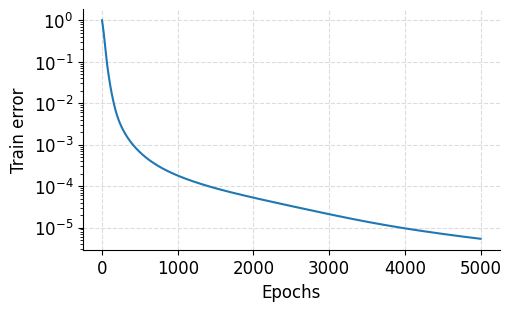

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Epochs")
ax.set_ylabel("Train error")

In [19]:
@partial(eqx.filter_vmap, in_axes=(None, 0, 0, None))
def jacobian_one_step_model(model, t, u, dt):
    @eqx.filter_jacrev
    def _jac_step(t_u):
        t, u = t_u
        return model.step(t, t + dt, u)

    return _jac_step((t, u))[1]

In [20]:
jac_nn = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn = relative_error(jac_nn, jac_true, axis=(-2, -1))

In [15]:
model = LatentLSTM(3, 30, key=0)
optimizer = optax.adabelief(learning_rate=2e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def step_fn_second_order(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = loss_grad_fn_second_order(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


loss_history = []
max_epochs = 5000
for epoch in range(max_epochs):
    loss, model, opt_state = step_fn_second_order(
        model, t_train, u_train, idx_nn, opt_state
    )
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(1.00663367, dtype=float64)
epoch=1, loss=Array(0.98436484, dtype=float64)
epoch=2, loss=Array(0.96135741, dtype=float64)
epoch=3, loss=Array(0.93771032, dtype=float64)
epoch=4, loss=Array(0.91350883, dtype=float64)
epoch=5, loss=Array(0.88885483, dtype=float64)
epoch=6, loss=Array(0.86389031, dtype=float64)
epoch=7, loss=Array(0.83880201, dtype=float64)
epoch=8, loss=Array(0.81380416, dtype=float64)
epoch=9, loss=Array(0.78910567, dtype=float64)
epoch=10, loss=Array(0.76487363, dtype=float64)
epoch=11, loss=Array(0.7412132, dtype=float64)
epoch=12, loss=Array(0.71817139, dtype=float64)
epoch=13, loss=Array(0.6957513, dtype=float64)
epoch=14, loss=Array(0.67392698, dtype=float64)
epoch=15, loss=Array(0.65265532, dtype=float64)
epoch=16, loss=Array(0.63188455, dtype=float64)
epoch=17, loss=Array(0.61156046, dtype=float64)
epoch=18, loss=Array(0.59163244, dtype=float64)
epoch=19, loss=Array(0.57205924, dtype=float64)
epoch=20, loss=Array(0.55281248, dtype=float64)
epoc

Text(0, 0.5, 'Train error')

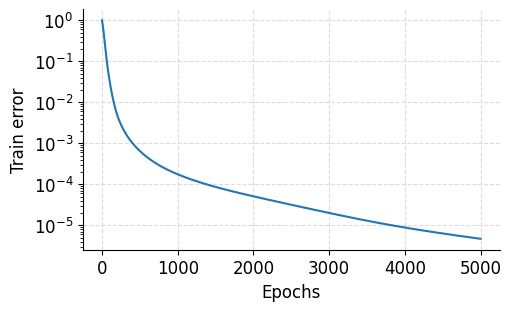

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Epochs")
ax.set_ylabel("Train error")

In [17]:
jac_nn2 = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn2 = relative_error(jac_nn2, jac_true, axis=(-2, -1))

In [24]:
from dynamics_discovery.io import load_model


model_loaded = load_model("results/lorenz63/latent_lstm/len=2_noise=0.0_key=0.eqx")

jac_nn_1step = jacobian_one_step_model(
    model_loaded, t_train, u_train, t_train[1] - t_train[0]
)
err_nn_1step = relative_error(jac_nn_1step, jac_true, axis=(-2, -1))

Text(0.5, 0.98, 'Relative jacobian error')

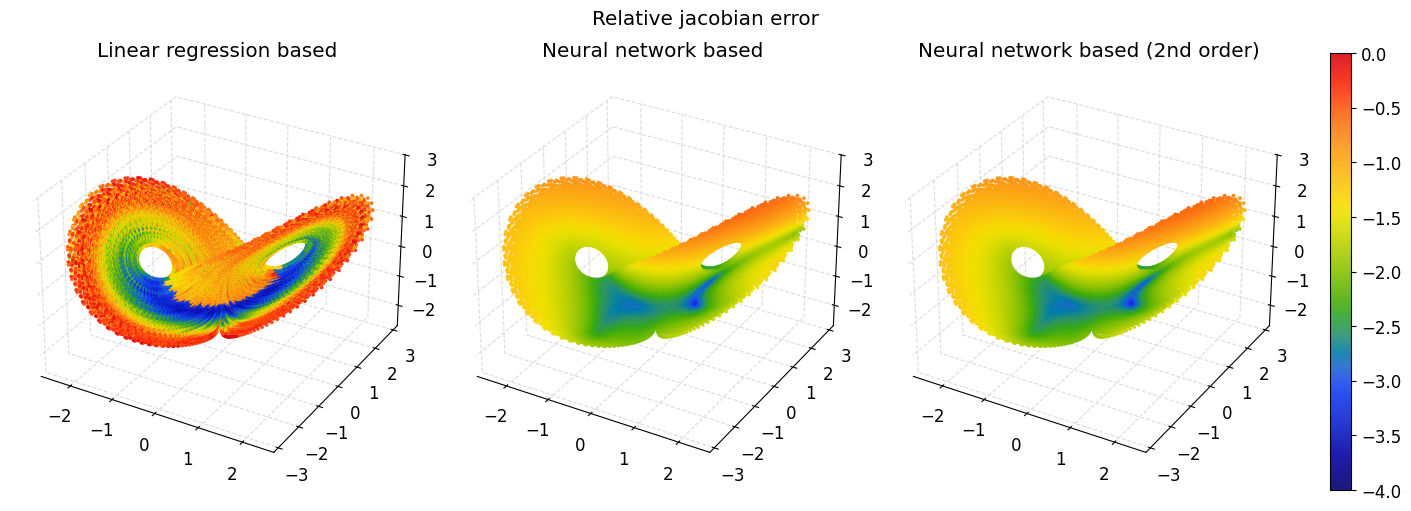

In [29]:
scatter_kwargs = {"s": 3, "cmap": cc.cm.rainbow4, "vmin": -4, "vmax": 0.0, "alpha": 0.9}
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)

axes[0].scatter(*u_train[1:].T, c=jnp.log10(err_linregress), **scatter_kwargs)
axes[1].scatter(*u_train.T, c=jnp.log10(err_nn), **scatter_kwargs)
ax = axes[2].scatter(*u_train.T, c=jnp.log10(err_nn2), **scatter_kwargs)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network based")
axes[2].set_title("Neural network based (2nd order)")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

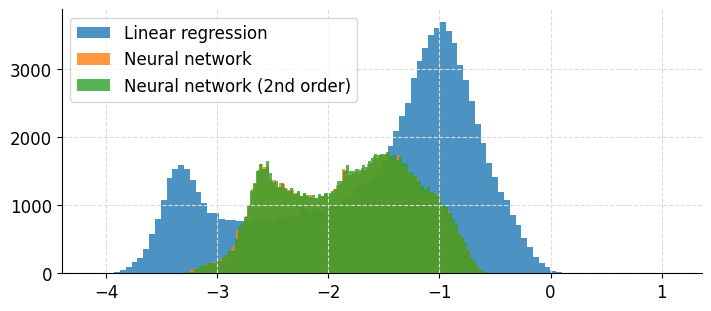

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
hist_kwargs = {"bins": 100, "alpha": 0.8}
ax.hist(jnp.log10(err_linregress), label="Linear regression", **hist_kwargs)
ax.hist(jnp.log10(err_nn), label="Neural network", **hist_kwargs)
ax.hist(jnp.log10(err_nn2), label="Neural network (2nd order)", **hist_kwargs)
ax.legend()

In [36]:
model = LatentLSTM(3, 30, key=0)
optimizer = optax.adabelief(learning_rate=2e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def hybrid_step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = hybrid_loss_grad_fn(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


In [37]:
loss_history = []
max_epochs = 20000
for epoch in range(max_epochs):
    loss, model, opt_state = hybrid_step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(2.01699215, dtype=float64)
epoch=1, loss=Array(2.01233105, dtype=float64)
epoch=2, loss=Array(2.00743824, dtype=float64)
epoch=3, loss=Array(2.00231209, dtype=float64)
epoch=4, loss=Array(1.99695179, dtype=float64)
epoch=5, loss=Array(1.99135727, dtype=float64)
epoch=6, loss=Array(1.98552909, dtype=float64)
epoch=7, loss=Array(1.97946838, dtype=float64)
epoch=8, loss=Array(1.97317695, dtype=float64)
epoch=9, loss=Array(1.96665718, dtype=float64)
epoch=10, loss=Array(1.95991203, dtype=float64)
epoch=11, loss=Array(1.95294493, dtype=float64)
epoch=12, loss=Array(1.9457597, dtype=float64)
epoch=13, loss=Array(1.93836051, dtype=float64)
epoch=14, loss=Array(1.93075173, dtype=float64)
epoch=15, loss=Array(1.92293792, dtype=float64)
epoch=16, loss=Array(1.91492372, dtype=float64)
epoch=17, loss=Array(1.90671378, dtype=float64)
epoch=18, loss=Array(1.8983127, dtype=float64)
epoch=19, loss=Array(1.889725, dtype=float64)
epoch=20, loss=Array(1.88095506, dtype=float64)
epoch=

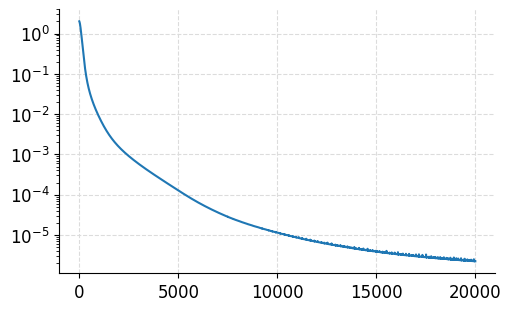

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)

In [39]:
jac_nn = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn = relative_error(jac_nn, jac_true, axis=(-2, -1))

Text(0.5, 0.98, 'Relative jacobian error')

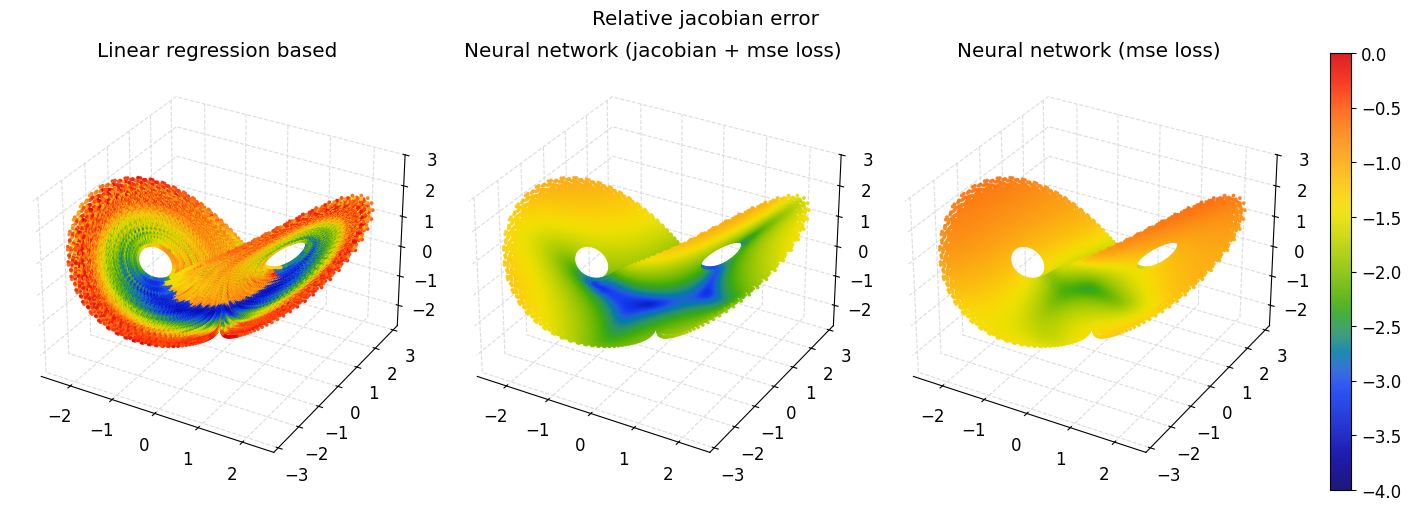

In [40]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)
scatter_kwargs = {"s": 3, "cmap": cc.cm.rainbow4, "vmin": -4, "vmax": 0.0, "alpha": 0.9}
axes[0].scatter(*u_train[1:].T, c=jnp.log10(err_linregress), **scatter_kwargs)
axes[1].scatter(*u_train.T, c=jnp.log10(err_nn), **scatter_kwargs)
ax = axes[2].scatter(*u_train.T, c=jnp.log10(err_nn_1step), **scatter_kwargs)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network (jacobian + mse loss)")
axes[2].set_title("Neural network (mse loss)")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

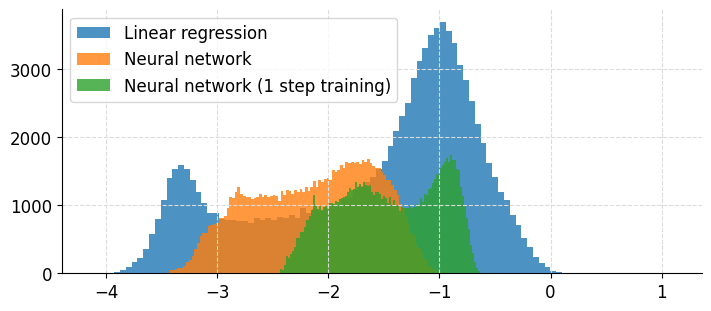

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.hist(jnp.log10(err_linregress), bins=100, label="Linear regression", alpha=0.8)
ax.hist(jnp.log10(err_nn), bins=100, label="Neural network", alpha=0.8)
ax.hist(
    jnp.log10(err_nn_1step),
    bins=100,
    label="Neural network (1 step training)",
    alpha=0.8,
)

ax.legend()

In [42]:
from dynamics_discovery.preprocessing import split_into_chunks


train_length = 2
noise = 0

t_train_batch = split_into_chunks(t_train, train_length)
u_train_batch = split_into_chunks(u_train, train_length)
# u_train_batch = add_noise(u_train_batch, noise, key=0)

subsample_factor = u_train_batch.shape[0] // 100
print(t_train_batch.shape)
u_pred_train = eqx.filter_vmap(model.solve)(
    t_train_batch[::subsample_factor], u_train_batch[::subsample_factor, 0]
)
u_pred_test = model.solve(t_train, u_train[0], max_steps=None)


(50000, 2)


Text(0.5, 0.98, 'Latent LSTM prediction (train length = 2, seed = 0)')

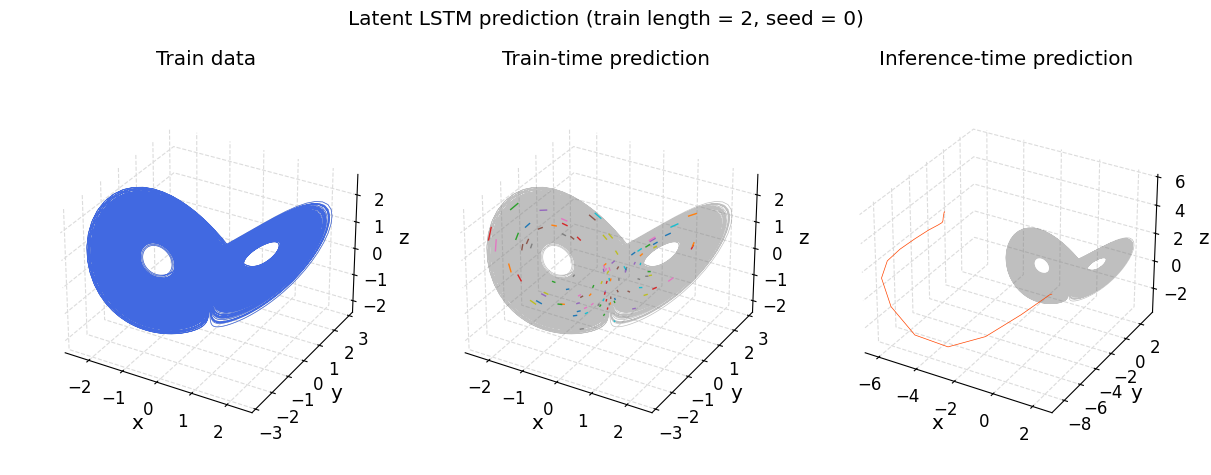

In [43]:
import numpy as np
from matplotlib_utils.axes_setters import set_labels


fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
plot_kwargs = {"linewidth": 0.5}
axes[0].set_title("Train data")
axes[0].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[0].plot(*u_train.T, color="royalblue", **plot_kwargs)

axes[1].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
for u_i in np.asarray(u_pred_train)[::]:
    axes[1].plot(*u_i.T, linewidth=1.0)
axes[1].set_title("Train-time prediction")
axes[2].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[2].plot(*u_pred_test.T, color="orangered", **plot_kwargs)
axes[2].set_title("Inference-time prediction")

for ax in axes:
    set_labels(ax, ["x", "y", "z"], fontsize="large")
    ax.set_box_aspect(None, zoom=0.85)
    ax.set_title
fig.suptitle(f"Latent LSTM prediction (train length = {train_length}, seed = 0)")


In [ ]:
model = LatentLSTM(3, 30, key=0)
optimizer = optax.adabelief(learning_rate=2e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def hybrid_step_fn_second_order(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = hybrid_loss_grad_fn_second_order(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


loss_history = []
max_epochs = 5000
for epoch in range(max_epochs):
    loss, model, opt_state = hybrid_step_fn_second_order(
        model, t_train, u_train, idx_nn, opt_state
    )
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(2.01699399, dtype=float64)
epoch=1, loss=Array(2.01233266, dtype=float64)
epoch=2, loss=Array(2.00743961, dtype=float64)
epoch=3, loss=Array(2.00231321, dtype=float64)
epoch=4, loss=Array(1.99695264, dtype=float64)
epoch=5, loss=Array(1.99135785, dtype=float64)
epoch=6, loss=Array(1.98552937, dtype=float64)
epoch=7, loss=Array(1.97946837, dtype=float64)
epoch=8, loss=Array(1.97317661, dtype=float64)
epoch=9, loss=Array(1.96665651, dtype=float64)
epoch=10, loss=Array(1.95991101, dtype=float64)
epoch=11, loss=Array(1.95294354, dtype=float64)
epoch=12, loss=Array(1.94575794, dtype=float64)
epoch=13, loss=Array(1.93835835, dtype=float64)
epoch=14, loss=Array(1.93074916, dtype=float64)
epoch=15, loss=Array(1.92293493, dtype=float64)
epoch=16, loss=Array(1.91492029, dtype=float64)
epoch=17, loss=Array(1.90670989, dtype=float64)
epoch=18, loss=Array(1.89830835, dtype=float64)
epoch=19, loss=Array(1.88972016, dtype=float64)
epoch=20, loss=Array(1.88094972, dtype=float64)
ep